# **Regression Project**


## **Loading data set**

In [1]:
from sklearn.datasets import fetch_california_housing
import pandas as pd

# Load dataset
housing = fetch_california_housing()

# Convert to DataFrame
df = pd.DataFrame(housing.data, columns=housing.feature_names)

# Add target column
df['MedHouseVal'] = housing.target

df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [2]:
df.columns

Index(['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup',
       'Latitude', 'Longitude', 'MedHouseVal'],
      dtype='str')

## **Exploratory Data Analysis**

### Features

In [3]:
housing_features=df.drop('MedHouseVal', axis=1)
housing_features

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25
...,...,...,...,...,...,...,...,...
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32


### Rows and columns

In [4]:
print("Rows, Columns=", df.shape)

Rows, Columns= (20640, 9)


### Checking for Missing values

In [5]:
df.isnull().sum()

MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64

### Summary Statistics

In [6]:
df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


### Target Distribution

<Axes: >

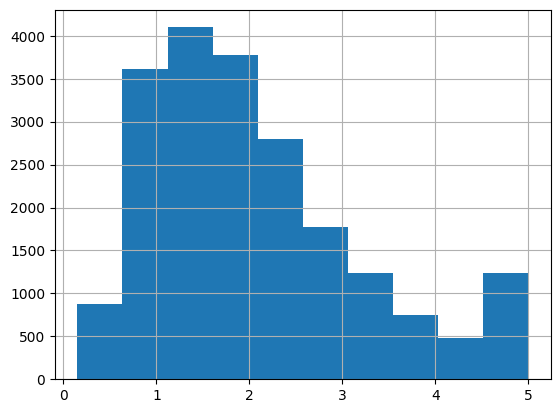

In [7]:
df['MedHouseVal'].hist()

### Correlation Matrix

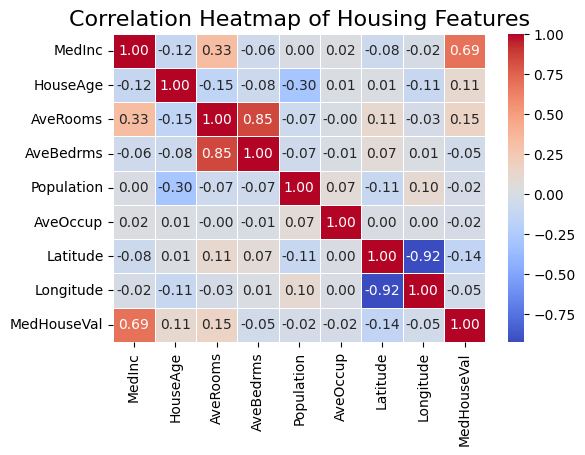

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

corr_matrix = df.corr()
plt.figure(figsize=(6, 4))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap of Housing Features', fontsize=16)
plt.show()

## **Pipeline**

In [9]:
from sklearn import pipeline
from sklearn.compose import ColumnTransformer
import numpy as np
import pandas as pd

### **Model Testing**

#### Data split

In [10]:
y=df['MedHouseVal']
y

0        4.526
1        3.585
2        3.521
3        3.413
4        3.422
         ...  
20635    0.781
20636    0.771
20637    0.923
20638    0.847
20639    0.894
Name: MedHouseVal, Length: 20640, dtype: float64

In [11]:
X=housing_features
X

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25
...,...,...,...,...,...,...,...,...
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32


In [12]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=100, shuffle=True)

In [13]:
X_train

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
3278,3.3929,13.0,8.580645,1.790323,214.0,3.451613,39.14,-122.70
16630,3.2226,11.0,4.927273,1.062121,1814.0,2.748485,35.32,-120.83
18748,3.3500,18.0,5.710638,1.018440,1731.0,2.455319,40.49,-122.31
14961,5.2741,7.0,6.855372,0.979339,862.0,3.561983,32.76,-116.92
1740,2.3382,19.0,4.059891,1.052632,1438.0,2.609800,37.97,-122.34
...,...,...,...,...,...,...,...,...
16304,10.0088,15.0,7.738854,1.003185,1016.0,3.235669,38.01,-121.37
79,2.0114,38.0,4.412903,1.135484,344.0,2.219355,37.80,-122.28
12119,5.6409,3.0,7.837746,1.083262,8437.0,3.602477,33.97,-117.21
14147,2.3812,35.0,6.289474,1.109649,753.0,3.302632,32.74,-117.08


In [14]:
X_test

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
8151,3.7031,36.0,6.276836,1.039548,444.0,2.508475,33.81,-118.10
53,1.2475,52.0,4.075000,1.140000,1162.0,2.905000,37.82,-122.27
3039,4.8266,13.0,6.746647,1.062593,2170.0,3.233979,35.37,-119.12
9484,2.8833,19.0,6.750000,1.348684,424.0,2.789474,39.31,-123.15
9307,2.8903,31.0,4.477459,1.073087,2962.0,2.023224,37.98,-122.52
...,...,...,...,...,...,...,...,...
16733,2.1154,8.0,4.288660,1.247423,936.0,9.649485,35.47,-120.64
5264,11.2866,14.0,7.271898,1.041971,2926.0,2.669708,34.09,-118.57
12374,3.3799,6.0,10.860423,2.036020,4176.0,1.880234,33.78,-116.36
19662,1.7227,52.0,4.954023,1.011494,922.0,2.649425,37.50,-120.85


---
#### Linear Regression


In [15]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


##### Predictions for LR

In [16]:
y_lr_train_pred = lr.predict(X_train)
y_lr_test_pred  = lr.predict(X_test)

In [17]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Training
lr_train_mae  = mean_absolute_error(y_train, y_lr_train_pred)
lr_train_mse  = mean_squared_error(y_train, y_lr_train_pred)
lr_train_rmse = np.sqrt(lr_train_mse)
lr_train_r2   = r2_score(y_train, y_lr_train_pred)

# Testing
lr_test_mae  = mean_absolute_error(y_test, y_lr_test_pred)
lr_test_mse  = mean_squared_error(y_test, y_lr_test_pred)
lr_test_rmse = np.sqrt(lr_test_mse)
lr_test_r2   = r2_score(y_test, y_lr_test_pred)

LRmetrics = pd.DataFrame({
    "Metric": ["MAE", "MSE", "RMSE", "R2"],
    "Train":  [lr_train_mae, lr_train_mse, lr_train_rmse, lr_train_r2],
    "Test":   [lr_test_mae,  lr_test_mse,  lr_test_rmse,  lr_test_r2]
})
print(LRmetrics)

  Metric     Train      Test
0    MAE  0.532891  0.527773
1    MSE  0.528259  0.508893
2   RMSE  0.726815  0.713368
3     R2  0.602078  0.622314


---
#### Random Forest


In [18]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV

In [19]:
param_grid_rf = {
    "n_estimators":     [100, 200, 300],
    "max_depth":        [None, 10],
    "min_samples_split":[2, 5],
    "min_samples_leaf": [1, 2],
    "max_features":     ["sqrt", 0.5]
}

In [20]:
grid_search_rf = GridSearchCV(
    estimator=RandomForestRegressor(random_state=45, n_jobs=-1),
    param_grid=param_grid_rf,
    cv=3,
    scoring="neg_mean_squared_error",
    verbose=1
)
grid_search_rf.fit(X_train, y_train)

Fitting 3 folds for each of 48 candidates, totalling 144 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestR...ndom_state=45)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [None, 10], 'max_features': ['sqrt', 0.5], 'min_samples_leaf': [1, 2], 'min_samples_split': [2, 5], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each f

In [21]:
grid_search_rf.best_params_

{'max_depth': None,
 'max_features': 'sqrt',
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'n_estimators': 200}

##### Predictions for RF

In [22]:
y_rf_train_pred = grid_search_rf.best_estimator_.predict(X_train)
y_rf_test_pred  = grid_search_rf.best_estimator_.predict(X_test)

In [23]:
# Training
rf_train_mae  = mean_absolute_error(y_train, y_rf_train_pred)
rf_train_mse  = mean_squared_error(y_train, y_rf_train_pred)
rf_train_rmse = np.sqrt(rf_train_mse)
rf_train_r2   = r2_score(y_train, y_rf_train_pred)

# Testing
rf_test_mae  = mean_absolute_error(y_test, y_rf_test_pred)
rf_test_mse  = mean_squared_error(y_test, y_rf_test_pred)
rf_test_rmse = np.sqrt(rf_test_mse)
rf_test_r2   = r2_score(y_test, y_rf_test_pred)

RFmetrics = pd.DataFrame({
    "Metric": ["MAE", "MSE", "RMSE", "R2"],
    "Train":  [rf_train_mae, rf_train_mse, rf_train_rmse, rf_train_r2],
    "Test":   [rf_test_mae,  rf_test_mse,  rf_test_rmse,  rf_test_r2]
})
print(RFmetrics)

  Metric     Train      Test
0    MAE  0.121283  0.320642
1    MSE  0.033265  0.225309
2   RMSE  0.182387  0.474667
3     R2  0.974942  0.832782


---
#### Gradient Boosting


In [24]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, uniform

In [25]:
param_dist_gb = {
    "n_estimators":      randint(100, 300),
    "learning_rate":     uniform(0.01, 0.09),
    "max_depth":         randint(3, 6),
    "min_samples_split": randint(2, 6),
    "min_samples_leaf":  randint(1, 3),
    "subsample":         uniform(0.8, 0.2)
}

In [26]:
random_search_gb = RandomizedSearchCV(
    estimator=GradientBoostingRegressor(random_state=100),
    param_distributions=param_dist_gb,
    n_iter=50,
    cv=3,
    scoring="neg_mean_squared_error",
    verbose=1,
    random_state=100
)
random_search_gb.fit(X_train, y_train)

Fitting 3 folds for each of 50 candidates, totalling 150 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",GradientBoost...dom_state=100)
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'learning_rate': <scipy.stats....002DA5CE397F0>, 'max_depth': <scipy.stats....002DA6006CCD0>, 'min_samples_leaf': <scipy.stats....002DA5CC67490>, 'min_samples_split': <scipy.stats....002DA6006CF50>, ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",50
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'neg_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.

In [27]:
random_search_gb.best_params_

{'learning_rate': np.float64(0.08016385587496747),
 'max_depth': 5,
 'min_samples_leaf': 1,
 'min_samples_split': 3,
 'n_estimators': 279,
 'subsample': np.float64(0.9395469815025912)}

##### Predictions for GB

In [28]:
y_gb_train_pred = random_search_gb.best_estimator_.predict(X_train)
y_gb_test_pred  = random_search_gb.best_estimator_.predict(X_test)

In [29]:
# Training
gb_train_mae  = mean_absolute_error(y_train, y_gb_train_pred)
gb_train_mse  = mean_squared_error(y_train, y_gb_train_pred)
gb_train_rmse = np.sqrt(gb_train_mse)
gb_train_r2   = r2_score(y_train, y_gb_train_pred)

# Testing
gb_test_mae  = mean_absolute_error(y_test, y_gb_test_pred)
gb_test_mse  = mean_squared_error(y_test, y_gb_test_pred)
gb_test_rmse = np.sqrt(gb_test_mse)
gb_test_r2   = r2_score(y_test, y_gb_test_pred)

GBmetrics = pd.DataFrame({
    "Metric": ["MAE", "MSE", "RMSE", "R2"],
    "Train":  [gb_train_mae, gb_train_mse, gb_train_rmse, gb_train_r2],
    "Test":   [gb_test_mae,  gb_test_mse,  gb_test_rmse,  gb_test_r2]
})
print(GBmetrics)

  Metric     Train      Test
0    MAE  0.243459  0.300940
1    MSE  0.118817  0.207190
2   RMSE  0.344699  0.455181
3     R2  0.910498  0.846230


---
#### XGBoost


In [30]:
from xgboost import XGBRegressor
from hyperopt import fmin, tpe, hp, STATUS_OK, Trials, space_eval
from sklearn.model_selection import cross_val_score

ModuleNotFoundError: No module named 'pkg_resources'

In [ ]:
space_xgb = {
    "n_estimators":     hp.choice("n_estimators",    [50, 100, 150, 200]),
    "learning_rate":    hp.loguniform("learning_rate", -4.6, -1.6),
    "max_depth":        hp.randint("max_depth",        3, 9),
    "subsample":        hp.uniform("subsample",        0.8, 1.0),
    "colsample_bytree": hp.uniform("colsample_bytree", 0.8, 1.0),
    "gamma":            hp.uniform("gamma",            0, 0.2)
}

In [ ]:
def xgb_objective(params):
    model = XGBRegressor(**params)
    scores = cross_val_score(model, X_train, y_train, cv=3,
                             scoring="neg_mean_absolute_error")
    return {"loss": -scores.mean(), "status": STATUS_OK}

xgb_trials     = Trials()
xgb_best_params = fmin(fn=xgb_objective, space=space_xgb,
                        algo=tpe.suggest, max_evals=50, trials=xgb_trials)

100%|██████████| 50/50 [02:44<00:00,  3.29s/trial, best loss: 0.30335139179410914]


In [ ]:
xgb_best = XGBRegressor(**space_eval(space_xgb, xgb_best_params))
xgb_best.fit(X_train, y_train)

space_eval(space_xgb, xgb_best_params)

{'colsample_bytree': 0.8488611929934546,
 'gamma': 0.11121455869763788,
 'learning_rate': 0.05983347800748877,
 'max_depth': np.int64(8),
 'n_estimators': 200,
 'subsample': 0.8068900992292894}

##### Predictions for XGBoost

In [ ]:
y_xgb_train_pred = xgb_best.predict(X_train)
y_xgb_test_pred  = xgb_best.predict(X_test)

In [ ]:
# Training
xgb_train_mae  = mean_absolute_error(y_train, y_xgb_train_pred)
xgb_train_mse  = mean_squared_error(y_train, y_xgb_train_pred)
xgb_train_rmse = np.sqrt(xgb_train_mse)
xgb_train_r2   = r2_score(y_train, y_xgb_train_pred)

# Testing
xgb_test_mae  = mean_absolute_error(y_test, y_xgb_test_pred)
xgb_test_mse  = mean_squared_error(y_test, y_xgb_test_pred)
xgb_test_rmse = np.sqrt(xgb_test_mse)
xgb_test_r2   = r2_score(y_test, y_xgb_test_pred)

XGBmetrics = pd.DataFrame({
    "Metric": ["MAE", "MSE", "RMSE", "R2"],
    "Train":  [xgb_train_mae, xgb_train_mse, xgb_train_rmse, xgb_train_r2],
    "Test":   [xgb_test_mae,  xgb_test_mse,  xgb_test_rmse,  xgb_test_r2]
})
print(XGBmetrics)

  Metric     Train      Test
0    MAE  0.172880  0.285841
1    MSE  0.059380  0.193302
2   RMSE  0.243679  0.439661
3     R2  0.955271  0.856537


---
## Voting Ensemble

In [ ]:
from sklearn.ensemble import VotingRegressor


voting_reg = VotingRegressor(
    estimators=[
        ('lr',  lr),
        ('rf',  grid_search_rf.best_estimator_),
        ('gb',  random_search_gb.best_estimator_),
        ('xgb', xgb_best)
    ]
)

voting_reg.fit(X_train, y_train)

,"estimators estimators: list of (str, estimator) tuplesInvoking the ``fit`` method on the ``VotingRegressor`` will fit clonesof those original estimators that will be stored in the class attribute``self.estimators_``. An estimator can be set to ``'drop'`` using:meth:`set_params`... versionchanged:: 0.21 ``'drop'`` is accepted. Using None was deprecated in 0.22 and support was removed in 0.24.","[('lr', ...), ('rf', ...), ...]"
,"weights weights: array-like of shape (n_regressors,), default=NoneSequence of weights (`float` or `int`) to weight the occurrences ofpredicted values before averaging. Uses uniform weights if `None`.",None
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for ``fit``.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting will be printed as itis completed... versionadded:: 0.23",False
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'


### Predictions

In [ ]:
y_vote_train_pred = voting_reg.predict(X_train)
y_vote_test_pred  = voting_reg.predict(X_test)

### Voting Metrics

In [ ]:
vote_train_mae  = mean_absolute_error(y_train, y_vote_train_pred)
vote_train_mse  = mean_squared_error(y_train, y_vote_train_pred)
vote_train_rmse = np.sqrt(vote_train_mse)
vote_train_r2   = r2_score(y_train, y_vote_train_pred)

vote_test_mae  = mean_absolute_error(y_test, y_vote_test_pred)
vote_test_mse  = mean_squared_error(y_test, y_vote_test_pred)
vote_test_rmse = np.sqrt(vote_test_mse)
vote_test_r2   = r2_score(y_test, y_vote_test_pred)

VOTEmetrics = pd.DataFrame({
    "Metric": ["MAE", "MSE", "RMSE", "R2"],
    "Train":  [vote_train_mae, vote_train_mse, vote_train_rmse, vote_train_r2],
    "Test":   [vote_test_mae,  vote_test_mse,  vote_test_rmse,  vote_test_r2]
})
print(VOTEmetrics)

  Metric     Train      Test
0    MAE  0.240716  0.327508
1    MSE  0.112540  0.227602
2   RMSE  0.335469  0.477076
3     R2  0.915227  0.831080


---
## Metric Comparison

In [ ]:
pd.set_option('display.width', 1000)
pd.set_option('display.max_columns', None)

results = pd.DataFrame({
    "Model":      ["Linear Regression", "Random Forest (GridSearch)",
                   "Gradient Boosting (RandomSearch)", "XGBoost (Hyperopt)"],
    "Train MAE":  [lr_train_mae,  rf_train_mae,  gb_train_mae,  xgb_train_mae],
    "Test MAE":   [lr_test_mae,   rf_test_mae,   gb_test_mae,   xgb_test_mae],
    "Train MSE":  [lr_train_mse,  rf_train_mse,  gb_train_mse,  xgb_train_mse],
    "Test MSE":   [lr_test_mse,   rf_test_mse,   gb_test_mse,   xgb_test_mse],
    "Train RMSE": [lr_train_rmse, rf_train_rmse, gb_train_rmse, xgb_train_rmse],
    "Test RMSE":  [lr_test_rmse,  rf_test_rmse,  gb_test_rmse,  xgb_test_rmse],
    "Train R2":   [lr_train_r2,   rf_train_r2,   gb_train_r2,   xgb_train_r2],
    "Test R2":    [lr_test_r2,    rf_test_r2,    gb_test_r2,    xgb_test_r2]
})

print(results)

                              Model  Train MAE  Test MAE  Train MSE  Test MSE  Train RMSE  Test RMSE  Train R2   Test R2
0                 Linear Regression   0.532891  0.527773   0.528259  0.508893    0.726815   0.713368  0.602078  0.622314
1        Random Forest (GridSearch)   0.121452  0.321606   0.033132  0.226866    0.182023   0.476305  0.975042  0.831626
2  Gradient Boosting (RandomSearch)   0.243459  0.300940   0.118817  0.207190    0.344699   0.455181  0.910498  0.846230
3                XGBoost (Hyperopt)   0.172880  0.285841   0.059380  0.193302    0.243679   0.439661  0.955271  0.856537


In [ ]:
VOTEmetrics = pd.DataFrame({
    "Metric": ["MAE", "MSE", "RMSE", "R2"],
    "Train":  [vote_train_mae, vote_train_mse, vote_train_rmse, vote_train_r2],
    "Test":   [vote_test_mae,  vote_test_mse,  vote_test_rmse,  vote_test_r2]
})
print(VOTEmetrics)

  Metric     Train      Test
0    MAE  0.240716  0.327508
1    MSE  0.112540  0.227602
2   RMSE  0.335469  0.477076
3     R2  0.915227  0.831080


## Notes

| Model | Tuning Method | Source File |
|---|---|---|
| Linear Regression | None | `Model__improv.ipynb` |
| Random Forest | GridSearchCV | `Model__improv.ipynb` |
| Gradient Boosting | RandomizedSearchCV | `Model-Side_tests.ipynb` |
| XGBoost | Hyperopt (TPE) | `Model_hyperopt.ipynb` |

## File Save

In [ ]:
import joblib
import os

# Create folder if it doesn't exist
os.makedirs("models", exist_ok=True)

joblib.dump(lr, 'models/California_homesLR.pkl')
joblib.dump(grid_search_rf.best_estimator_, 'models/California_homesRF.pkl')
joblib.dump(random_search_gb.best_estimator_, 'models/California_homesGB.pkl')
joblib.dump(xgb_best, 'models/California_homesXGB.pkl')

['models/California_homesXGB.pkl']